# Haber Başlığı Ödev Projesi

Bu notebook, **veri çekme scriptlerinden sonra** çalışır.

## Öğrenciler
- Mustafa Mete / 2202131015
- Emine Avcu / 2202131006

## Akış
1. Parametreleri tanımla ve ekrana yazdır.
2. Ham veriyi oku.
3. Başlıkları normalize et (NLTK stopwords kullanarak).
4. Duplicate çiftleri TF-IDF + cosine ile bul.
5. Sonuçları kaydet.

## 2. Veri Seti Seçimi ve Raporlama

### Kaynak
- Veri seti dosyası: `data/all/headlines_all.json`
- Veri toplama yöntemi: Python botları ile API + web/RSS tabanlı toplama, ardından tek havuzda birleştirme (`append-mode`).
- Kullanılan kaynaklar ve URL'ler:
  - NewsData API: `https://newsdata.io/api/1/news`
  - NewsAPI (Top Headlines / Sources): `https://newsapi.org/`
  - Google News RSS Search: `https://news.google.com/rss/search`
  - Google Search (web sonuçları): `https://www.google.com/search`
- Not: Toplanan kayıtlar `title`, `source`, `link`, `pubDate`, `fetchedAt` alanlarıyla standartlaştırılmıştır.

### Boyut
- Toplam doküman (ham kayıt) sayısı: **2805**
- Orijinal dosya formatı: **JSON**
- Orijinal dosya boyutu: **1.449 MB** (`headlines_all.json`)
- Eşlenik CSV dosyası: **1.187 MB** (`headlines_all.csv`)

### Sütun Yapısı
Aşağıdaki kolonlar modelleme için anlamlı ve düzenli bir yapıda tutulmuştur:

- `title`: Haber başlığı (ham metin)
- `source`: Haber kaynağı/site adı
- `link`: Haber URL'si
- `pubDate`: Yayın tarihi
- `fetchedAt`: Verinin çekildiği zaman damgası

Notebook içindeki normalizasyon adımında ek olarak aşağıdaki alan üretilmiştir:
- `normalized_title`: Temizlenmiş/normalize edilmiş başlık metni

### CSV Düzenleme Notu
- UTF-8 kodlama kullanılmıştır.
- Alan adları sabittir ve tüm kayıtlar aynı şemaya göre yazılmıştır.
- Tekrarlı kayıtlar `title+source+link+pubDate` anahtarına göre temizlenmiştir.
- Bu düzenli yapı, sonraki model eğitimi adımları için doğrudan kullanılabilir durumdadır.

In [293]:
import csv
import html
import json
import re
import unicodedata
from pathlib import Path
from pprint import pprint

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print('[1/11] Kutuphaneler yuklendi.')

[1/11] Kutuphaneler yuklendi.


In [295]:
# Tum pipeline parametreleri tek bir yapida tutuluyor.
CONFIG = {
    'input_json': Path(r'C:/Users/musta/OneDrive/Masaüstü/Yapay Zeka Dersi/data/all/headlines_all.json'),
    'normalized_out_csv': Path(r'C:/Users/musta/OneDrive/Masaüstü/Yapay Zeka Dersi/data/processed/all/headlines_normalized_all.csv'),
    'normalized_out_json': Path(r'C:/Users/musta/OneDrive/Masaüstü/Yapay Zeka Dersi/data/processed/all/headlines_normalized_all.json'),
    'pairs_out_csv': Path(r'C:/Users/musta/OneDrive/Masaüstü/Yapay Zeka Dersi/data/results/all/duplicate_pairs_all.csv'),
    'pairs_out_json': Path(r'C:/Users/musta/OneDrive/Masaüstü/Yapay Zeka Dersi/data/results/all/duplicate_pairs_all.json'),
    'threshold': 0.85,
    'language': 'english'
}

print('[2/11] Konfigurasyon hazirlandi.')

[2/11] Konfigurasyon hazirlandi.


In [297]:
# Parametreleri acik ve okunabilir sekilde yazdir.
print('=== PIPELINE PARAMETRELERI ===')
print(f"input_json          : {CONFIG['input_json']}")
print(f"normalized_out_csv  : {CONFIG['normalized_out_csv']}")
print(f"normalized_out_json : {CONFIG['normalized_out_json']}")
print(f"pairs_out_csv       : {CONFIG['pairs_out_csv']}")
print(f"pairs_out_json      : {CONFIG['pairs_out_json']}")
print(f"threshold           : {CONFIG['threshold']:.2f}")
print(f"language            : {CONFIG['language']}")

=== PIPELINE PARAMETRELERI ===
input_json          : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\all\headlines_all.json
normalized_out_csv  : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\processed\all\headlines_normalized_all.csv
normalized_out_json : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\processed\all\headlines_normalized_all.json
pairs_out_csv       : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\results\all\duplicate_pairs_all.csv
pairs_out_json      : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\results\all\duplicate_pairs_all.json
threshold           : 0.85
language            : english


In [299]:
# Gerekli NLTK corpus'unu indir.
# Not: Daha once indirildiyse tekrar indirmez.
nltk.download('stopwords', quiet=True)

# Dile gore stopwords seti olustur.
LANG_STOPWORDS = set(stopwords.words(CONFIG['language']))
print(f'Stopwords yuklendi. Toplam: {len(LANG_STOPWORDS)}')

Stopwords yuklendi. Toplam: 198


## 3. Ön İşleme (Pre-processing) Aşamaları

Bu bölümde aşağıdaki adımlar sırasıyla uygulanmıştır:
1. Genel içerik temizliği (HTML, özel karakter, sayı, gereksiz semboller)
2. Lowercasing
3. Tokenization (cümle yapısı korunarak)
4. Stop Word Removal
5. Lemmatization
6. Stemming

Her adım için `Önce/Sonra` çıktıları üretilmektedir.

In [302]:
# NLTK kutuphaneleri (tokenization, stopword, lemmatization, stemming) icin gerekli veri paketleri.
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize  # NLTK: sentence/word tokenization
from nltk.corpus import stopwords  # NLTK: stopword removal
from nltk.stem import WordNetLemmatizer, PorterStemmer  # NLTK: lemmatization + stemming
import re  # re: regex tabanli temizlik
import html  # html: HTML entity cozumleme

nltk.download('punkt', quiet=True)
# Bazi NLTK surumlerinde sentence tokenizer icin ek kaynak gerekebilir.
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Dile ozgu stopword seti (NLTK)
EN_STOPWORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
STEMMER = PorterStemmer()

# Veri setinden metinleri al (headlines_all.json)
with CONFIG['input_json'].open('r', encoding='utf-8') as f:
    pp_raw_records = json.load(f)

# Pre-processing gosterimi icin veri setinden ilk dolu 5 basligi sec
dataset_texts = []
for item in pp_raw_records:
    title = (item.get('title') or '').strip()
    if title:
        dataset_texts.append(title)
    if len(dataset_texts) == 5:
        break

print('Pre-processing veri seti hazirlandi. Toplam secilen kayit:', len(dataset_texts))

Pre-processing veri seti hazirlandi. Toplam secilen kayit: 5


In [306]:
# ==============================
# 1) Genel Icerik Temizlik (re + html)
# ==============================
def clean_general_content(text: str) -> str:
    # html kutuphanesi: HTML entity (ornegin &amp;) cozumleme
    text = html.unescape(text)

    # re kutuphanesi: HTML etiketleri temizleme
    text = re.sub(r'<[^>]+>', ' ', text)

    # re kutuphanesi: URL temizleme
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # re kutuphanesi: sayi temizleme
    text = re.sub(r'\d+', ' ', text)

    # re kutuphanesi: noktalama disi ozel karakter/simge temizleme
    # Cumle noktalari (. ! ?) korunuyor; sentence tokenization icin gerekli.
    text = re.sub(r"[^\w\s\.!\?]", ' ', text)

    # Fazla bosluklari sadele
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# ==============================
# 2) Lowercasing
# ==============================
def to_lowercase(text: str) -> str:
    return text.lower()


# ==============================
# 3) Tokenization (NLTK)
# ==============================
def tokenize_with_sentences(text: str):
    # NLTK sent_tokenize: Cumleleri korur
    sentences = sent_tokenize(text)

    # NLTK word_tokenize: Her cumleyi kelimelere ayirir
    tokenized_sentences = []
    for sent in sentences:
        tokens = word_tokenize(sent)
        # Cumle sonu noktalama tokenlarini at
        tokens = [tok for tok in tokens if tok not in {'.', '!', '?', ',', ';', ':', '"', "'", '``', "''"}]
        tokenized_sentences.append(tokens)
    return sentences, tokenized_sentences


# ==============================
# 4) Stop Word Removal (NLTK)
# ==============================
def remove_stopwords(tokenized_sentences):
    cleaned = []
    for sent_tokens in tokenized_sentences:
        cleaned.append([tok for tok in sent_tokens if tok.lower() not in EN_STOPWORDS])
    return cleaned


# ==============================
# 5) Lemmatization (NLTK WordNetLemmatizer)
# ==============================
def lemmatize_tokens(tokenized_sentences):
    lemmatized = []
    for sent_tokens in tokenized_sentences:
        lemmatized.append([LEMMATIZER.lemmatize(tok.lower()) for tok in sent_tokens])
    return lemmatized


# ==============================
# 6) Stemming (NLTK PorterStemmer)
# ==============================
def stem_tokens(tokenized_sentences):
    stemmed = []
    for sent_tokens in tokenized_sentences:
        stemmed.append([STEMMER.stem(tok.lower()) for tok in sent_tokens])
    return stemmed


# ==============================
# ADIM ADIM ONCE/SONRA GOSTERIMI (VERI SETINDEN)
# ==============================
for idx, raw_text in enumerate(dataset_texts, start=1):
    print(f"\n{'=' * 80}")
    print(f"VERI SETI KAYDI {idx}")
    print(f"{'=' * 80}")

    # 1) Genel Icerik Temizlik
    cleaned = clean_general_content(raw_text)
    print("\n[1] Genel Icerik Temizlik (re + html)")
    print("ONCE :", raw_text)
    print("SONRA:", cleaned)

    # 2) Lowercasing
    lowered = to_lowercase(cleaned)
    print("\n[2] Lowercasing")
    print("ONCE :", cleaned)
    print("SONRA:", lowered)

    # 3) Tokenization (cumleleri koruyarak)
    sentences_before, tokenized = tokenize_with_sentences(lowered)
    print("\n[3] Tokenization (NLTK sent_tokenize + word_tokenize)")
    print("ONCE (Cumleler):", sentences_before)
    print("SONRA (Tokenlar):", tokenized)

    # 4) Stop Word Removal
    no_stop = remove_stopwords(tokenized)
    print("\n[4] Stop Word Removal (NLTK stopwords)")
    print("ONCE :", tokenized)
    print("SONRA:", no_stop)

    # 5) Lemmatization
    lemmatized = lemmatize_tokens(no_stop)
    print("\n[5] Lemmatization (NLTK WordNetLemmatizer)")
    print("ONCE :", no_stop)
    print("SONRA:", lemmatized)

    # 6) Stemming
    stemmed = stem_tokens(lemmatized)
    print("\n[6] Stemming (NLTK PorterStemmer)")
    print("ONCE :", lemmatized)
    print("SONRA:", stemmed)

print("\nTum pre-processing adimlari tamamlandi.")


VERI SETI KAYDI 1

[1] Genel Icerik Temizlik (re + html)
ONCE : U.S. stocks clock best month since 2020 as Wall Street shakes off Iran oil shock
SONRA: U.S. stocks clock best month since as Wall Street shakes off Iran oil shock

[2] Lowercasing
ONCE : U.S. stocks clock best month since as Wall Street shakes off Iran oil shock
SONRA: u.s. stocks clock best month since as wall street shakes off iran oil shock

[3] Tokenization (NLTK sent_tokenize + word_tokenize)
ONCE (Cumleler): ['u.s. stocks clock best month since as wall street shakes off iran oil shock']
SONRA (Tokenlar): [['u.s.', 'stocks', 'clock', 'best', 'month', 'since', 'as', 'wall', 'street', 'shakes', 'off', 'iran', 'oil', 'shock']]

[4] Stop Word Removal (NLTK stopwords)
ONCE : [['u.s.', 'stocks', 'clock', 'best', 'month', 'since', 'as', 'wall', 'street', 'shakes', 'off', 'iran', 'oil', 'shock']]
SONRA: [['u.s.', 'stocks', 'clock', 'best', 'month', 'since', 'wall', 'street', 'shakes', 'iran', 'oil', 'shock']]

[5] Lemmatiza

In [322]:
VERBOSE_NORMALIZE = True

# Baslik sonundaki kaynak etiketlerini temizler.
def strip_source_suffix(title: str) -> str:
    title = re.sub(r'\s*-\s*[^-]{2,80}$', '', title).strip()
    title = re.sub(r'\s*\|\s*[^|]{2,80}$', '', title).strip()
    return title

# Turkce karakterlerin ASCII benzeri formunu alir.
def remove_accents(text: str) -> str:
    normalized = unicodedata.normalize('NFKD', text)
    return ''.join(ch for ch in normalized if not unicodedata.combining(ch))

NOISE_TERMS = {
    'live', 'update', 'updates', 'video', 'photos', 'podcast', 'analysis',
    'opinion', 'exclusive', 'new', 'breaking', 'watch', 'report', 'latest'
}

# Tek bir basligi normalize eder.
def normalize_title(text: str) -> str:
    original = text

    text = html.unescape(text)
    text = strip_source_suffix(text)
    text = remove_accents(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\[[^\]]*\]|\([^\)]*\)', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)

    tokens = re.findall(r'[a-z0-9]+', text)

    cleaned_tokens = []
    for token in tokens:
        if token in LANG_STOPWORDS:
            continue
        if token in NOISE_TERMS:
            continue
        if token.isdigit():
            continue
        if len(token) < 3:
            continue
        cleaned_tokens.append(token)

    result = ' '.join(cleaned_tokens).strip()

    #if VERBOSE_NORMALIZE:
        #print(f"[normalize_title] Orijinal: {original}")
        #print(f"[normalize_title] Token sayisi: {len(tokens)}")
        #print(f"[normalize_title] Sonuc: {result}")

    return result


def write_csv(path: Path, rows, fieldnames):
    print(f"[write_csv] Yaziliyor: {path}")
    print(f"[write_csv] Satir sayisi: {len(rows)}")

    path.parent.mkdir(parents=True, exist_ok=True)

    with path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print("[write_csv] Tamamlandi")


def write_json(path: Path, data):
    print(f"[write_json] Yaziliyor: {path}")
    print(f"[write_json] Kayit sayisi: {len(data) if isinstance(data, list) else 'N/A'}")

    path.parent.mkdir(parents=True, exist_ok=True)

    path.write_text(
        json.dumps(data, ensure_ascii=False, indent=2),
        encoding='utf-8'
    )

    print("[write_json] Tamamlandi")


print('[4/11] Yardimci fonksiyonlar hazirlandi.')

[4/11] Yardimci fonksiyonlar hazirlandi.


In [324]:
input_path = CONFIG['input_json']
if not input_path.exists():
    raise FileNotFoundError(f'Girdi dosyasi bulunamadi: {input_path}')

raw_records = json.loads(input_path.read_text(encoding='utf-8'))
if not isinstance(raw_records, list):
    raise ValueError('Girdi JSON formati hatali. Liste bekleniyor.')

print(f'Ham kayit sayisi: {len(raw_records)}')

Ham kayit sayisi: 2805


In [326]:
normalized_records = []

for item in raw_records:
    # Bos veya eksik title kayitlarini atla.
    title = (item.get('title') or '').strip()
    if not title:
        continue

    normalized = normalize_title(title)
    if not normalized:
        continue

    normalized_records.append(
        {
            'title': title,
            'normalized_title': normalized,
            'source': item.get('source') or '',
            'link': item.get('link') or '',
            'pubDate': item.get('pubDate') or '',
        }
    )

print(f'Normalize kayit sayisi: {len(normalized_records)}')
print('Ornek normalize kayit:')
pprint(normalized_records[:2])

Normalize kayit sayisi: 2798
Ornek normalize kayit:
[{'link': 'https://www.marketwatch.com/bulletins/redirect/go?g=dab30966-8cf2-4a64-ba38-bbf711571f2f&mod=mw_rss_bulletins',
  'normalized_title': 'stocks clock best month since wall street shakes iran '
                      'oil shock',
  'pubDate': '2026-04-30 21:06:53',
  'source': 'marketwatch',
  'title': 'U.S. stocks clock best month since 2020 as Wall Street shakes off '
           'Iran oil shock'},
 {'link': 'https://us.headtopics.com/news/faa-chief-predicts-fewer-air-traffic-control-delays-this-82875820',
  'normalized_title': 'faa chief predicts fewer air traffic control delays '
                      'summer',
  'pubDate': '2026-04-30 21:06:40',
  'source': 'headtopics',
  'title': 'FAA chief predicts fewer air traffic control delays this summer'}]


In [328]:
write_csv(
    CONFIG['normalized_out_csv'],
    normalized_records,
    fieldnames=['title', 'normalized_title', 'source', 'link', 'pubDate'],
)
write_json(CONFIG['normalized_out_json'], normalized_records)

print(f"Normalize CSV kaydedildi: {CONFIG['normalized_out_csv']}")
print(f"Normalize JSON kaydedildi: {CONFIG['normalized_out_json']}")

[write_csv] Yaziliyor: C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\processed\all\headlines_normalized_all.csv
[write_csv] Satir sayisi: 2798
[write_csv] Tamamlandi
[write_json] Yaziliyor: C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\processed\all\headlines_normalized_all.json
[write_json] Kayit sayisi: 2798
[write_json] Tamamlandi
Normalize CSV kaydedildi: C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\processed\all\headlines_normalized_all.csv
Normalize JSON kaydedildi: C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\processed\all\headlines_normalized_all.json


In [330]:
if len(normalized_records) < 2:
    raise ValueError('Yeterli veri yok. En az 2 baslik gerekli.')

titles = [r['normalized_title'] for r in normalized_records]
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
matrix = vectorizer.fit_transform(titles)
sim_matrix = cosine_similarity(matrix)

print(f'TFIDF matrix boyutu: {matrix.shape}')
print(f'Similarity matrix boyutu: {sim_matrix.shape}')

TFIDF matrix boyutu: (2798, 22360)
Similarity matrix boyutu: (2798, 2798)


In [332]:
pairs = []
n = len(normalized_records)
threshold = CONFIG['threshold']

for i in range(n):
    for j in range(i + 1, n):
        score = float(sim_matrix[i, j])
        if score < threshold:
            continue

        a = normalized_records[i]
        b = normalized_records[j]
        source_a = (a['source'] or '').strip().lower()
        source_b = (b['source'] or '').strip().lower()
        link_a = (a['link'] or '').strip().lower()
        link_b = (b['link'] or '').strip().lower()

        # Ders kurali: ayni kaynak veya ayni link ise duplicate listesine alma.
        if source_a and source_b and source_a == source_b:
            continue
        if link_a and link_b and link_a == link_b:
            continue

        pairs.append(
            {
                'title_1': a['title'],
                'title_2': b['title'],
                'normalized_title_1': a['normalized_title'],
                'normalized_title_2': b['normalized_title'],
                'similarity': f'{score:.4f}',
                'source_1': a['source'],
                'source_2': b['source'],
                'link_1': a['link'],
                'link_2': b['link'],
                'pubDate_1': a['pubDate'],
                'pubDate_2': b['pubDate'],
            }
        )

print(f'Bulunan duplicate cift sayisi: {len(pairs)}')
print('Ilk 3 sonuc:')
pprint(pairs[:3])

Bulunan duplicate cift sayisi: 161
Ilk 3 sonuc:
[{'link_1': 'https://news.mongabay.com/2026/04/in-guatemala-new-ai-technology-will-be-listening-for-illegal-deforestation/',
  'link_2': 'https://news.google.com/rss/articles/CBMirgFBVV95cUxPVGM0aG1ZSFRLemxlV192d3ZuckktcE1ScVFUQ3BZM293SmpiLWlJRkdZbzMwZlNGbmg4Y0JpMlNveE1tY0JLMjZpdUxfeHlqd19JLWFlb3Q3VUkxQ2kzdkZsa3FibzV3aWJUUUVTY3IzM0hlUU5VZUxRdzhZYkRNaXJkYmI0bF8yUng3Z1JXeVd1S2I3Tmd2NDlBY0R0VUd2MDBFMWk1MzdRQ1dXUEHSAbMBQVVfeXFMTkFlaUVYRnlRX3RCc0ZpbjVmaE9PcWFnaHFINHFuUHBNVWJUVGV5cS1KUEdGb1VLNmxMV3FGM2xBcllUMnhUOTlJUXJmSE8xNUpBWWRBNzJLT19EQ3d2VjJYTnQ3c3c1QTlzRnQzWFNueGZFVlllUkFDbjZCM0VtRnZCaVEzN19ScXBVSmU0NXYyOWQtSEZJbTlpN3pmZTFyMEhHbWpKOXB4WXBDOV9iU1l4amc?oc=5',
  'normalized_title_1': 'guatemala technology listening illegal deforestation',
  'normalized_title_2': 'guatemala technology listening illegal deforestation '
                        'news',
  'pubDate_1': '2026-04-30 21:05:18',
  'pubDate_2': 'Thu, 30 Apr 2026 21:06:18 GMT',
  'simil

In [333]:
write_csv(
    CONFIG['pairs_out_csv'],
    pairs,
    fieldnames=[
        'title_1', 'title_2', 'normalized_title_1', 'normalized_title_2', 'similarity',
        'source_1', 'source_2', 'link_1', 'link_2', 'pubDate_1', 'pubDate_2'
    ],
)
write_json(CONFIG['pairs_out_json'], pairs)

print('\n=== PIPELINE OZETI ===')
print(f"Ham kayit sayisi         : {len(raw_records)}")
print(f"Normalize kayit sayisi   : {len(normalized_records)}")
print(f"Esik degeri              : {CONFIG['threshold']:.2f}")
print(f"Duplicate cift sayisi    : {len(pairs)}")
print(f"Normalize CSV            : {CONFIG['normalized_out_csv']}")
print(f"Normalize JSON           : {CONFIG['normalized_out_json']}")
print(f"Duplicate CSV            : {CONFIG['pairs_out_csv']}")
print(f"Duplicate JSON           : {CONFIG['pairs_out_json']}")

[write_csv] Yaziliyor: C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\results\all\duplicate_pairs_all.csv
[write_csv] Satir sayisi: 161
[write_csv] Tamamlandi
[write_json] Yaziliyor: C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\results\all\duplicate_pairs_all.json
[write_json] Kayit sayisi: 161
[write_json] Tamamlandi

=== PIPELINE OZETI ===
Ham kayit sayisi         : 2805
Normalize kayit sayisi   : 2798
Esik degeri              : 0.85
Duplicate cift sayisi    : 161
Normalize CSV            : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\processed\all\headlines_normalized_all.csv
Normalize JSON           : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\processed\all\headlines_normalized_all.json
Duplicate CSV            : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\results\all\duplicate_pairs_all.csv
Duplicate JSON           : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\results\all\duplicate_pairs_all.json


In [336]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

print('[11/11] Zipf kutuphaneleri yuklendi.')

[11/11] Zipf kutuphaneleri yuklendi.


Toplam token sayisi: 21428
Tekil kelime sayisi: 6619
En sik 15 kelime:
  technology: 153
  stock: 147
  market: 131
  global: 118
  innovation: 111
  energy: 107
  quantum: 107
  space: 104
  computing: 103
  cloud: 95
  business: 94
  iran: 93
  world: 88
  climate: 87
  software: 87
[{'frequency': 153, 'rank': 1, 'word': 'technology'},
 {'frequency': 147, 'rank': 2, 'word': 'stock'},
 {'frequency': 131, 'rank': 3, 'word': 'market'},
 {'frequency': 118, 'rank': 4, 'word': 'global'},
 {'frequency': 111, 'rank': 5, 'word': 'innovation'},
 {'frequency': 107, 'rank': 6, 'word': 'energy'},
 {'frequency': 107, 'rank': 7, 'word': 'quantum'},
 {'frequency': 104, 'rank': 8, 'word': 'space'},
 {'frequency': 103, 'rank': 9, 'word': 'computing'},
 {'frequency': 95, 'rank': 10, 'word': 'cloud'},
 {'frequency': 94, 'rank': 11, 'word': 'business'},
 {'frequency': 93, 'rank': 12, 'word': 'iran'},
 {'frequency': 88, 'rank': 13, 'word': 'world'},
 {'frequency': 87, 'rank': 14, 'word': 'climate'},
 {'fr

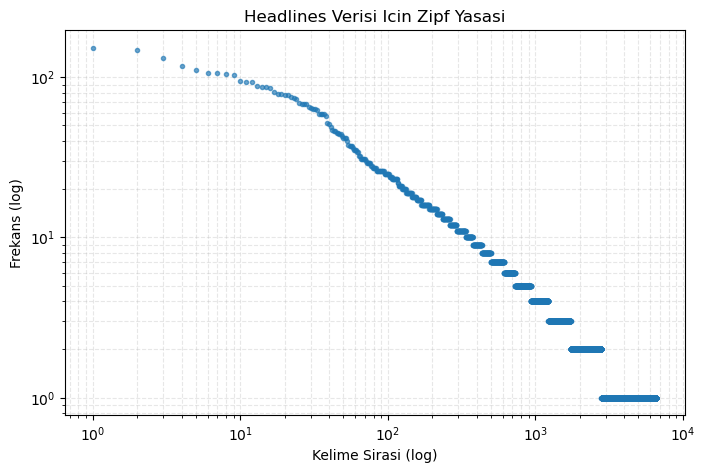

Log-log egim (ilk 300 rank): -0.628
Not: Eğim -1 civarına yaklaştıkça klasik Zipf davranışı daha belirgin olur.


In [338]:
# Normalize edilmis basliklardan tek bir token listesi olustur.
all_tokens = []
for rec in normalized_records:
    all_tokens.extend((rec.get('normalized_title') or '').split())

if not all_tokens:
    raise ValueError('Zipf analizi icin token bulunamadi.')

# Kelime frekanslarini hesapla.
word_freq = Counter(all_tokens)
sorted_items = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
sorted_freqs = [freq for _, freq in sorted_items]
ranks = np.arange(1, len(sorted_freqs) + 1)

print(f'Toplam token sayisi: {len(all_tokens)}')
print(f'Tekil kelime sayisi: {len(word_freq)}')
print('En sik 15 kelime:')
for word, freq in sorted_items[:15]:
    print(f'  {word}: {freq}')

# Rank-Frequency tablosunun ilk satirlarini goster.
zipf_preview = [
    {'rank': i + 1, 'word': sorted_items[i][0], 'frequency': sorted_items[i][1]}
    for i in range(min(20, len(sorted_items)))
]
pprint(zipf_preview)

# Zipf log-log grafigi.
plt.figure(figsize=(8, 5))
plt.loglog(ranks, sorted_freqs, marker='o', linestyle='none', markersize=3, alpha=0.65)
plt.xlabel('Kelime Sirasi (log)')
plt.ylabel('Frekans (log)')
plt.title('Headlines Verisi Icin Zipf Yasasi')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.show()

# Basit uyum ozeti (ilk N rank icin log-log lineer fit).
fit_n = min(300, len(sorted_freqs))
log_ranks = np.log(ranks[:fit_n])
log_freqs = np.log(np.array(sorted_freqs[:fit_n], dtype=float))
slope, intercept = np.polyfit(log_ranks, log_freqs, 1)
print(f'Log-log egim (ilk {fit_n} rank): {slope:.3f}')
print('Not: Eğim -1 civarına yaklaştıkça klasik Zipf davranışı daha belirgin olur.')

## 4. Ham Veri vs Temizlenmiş Veri vs Çıktı Veri (Açıklamalı)

Bu bölümde pipeline sonucunu anlaşılır şekilde görmek için üç veri katmanı birlikte gösterilir:

- **Ham veri (`headlines_all.json`)**: Botlardan/API kaynaklarından gelen orijinal kayıtlar.
- **Temizlenmiş veri (`headlines_normalized_all.csv/.json`)**: Ön işleme uygulanmış, modele uygun hale getirilmiş kayıtlar (`normalized_title` dahil).
- **Çıktı veri (`duplicate_pairs_all.csv/.json`)**: Benzerlik eşik değeri ile tespit edilen potansiyel duplicate çiftler.

Aşağıdaki hücre, her katman için:
1. Dosya yolu, kayıt sayısı ve boyut bilgisini,
2. İlk birkaç örnek kaydı,
3. Ham > temiz dönüşümünü (aynı kaydın `title` ve `normalized_title` karşılaştırması) üretir.

In [341]:
# json/csv/os kutuphaneleri: dosya okuma, satir analizi ve boyut bilgisi icin kullaniliyor.
import json
import csv
import os
from pprint import pprint


def read_json_records(path):
    with path.open('r', encoding='utf-8') as f:
        data = json.load(f)
    return data if isinstance(data, list) else []


def read_csv_records(path):
    with path.open('r', encoding='utf-8', newline='') as f:
        return list(csv.DictReader(f))


def mb(path):
    return round(path.stat().st_size / (1024 * 1024), 3)


raw_path = CONFIG['input_json']
clean_json_path = CONFIG['normalized_out_json']
clean_csv_path = CONFIG['normalized_out_csv']
pairs_json_path = CONFIG['pairs_out_json']
pairs_csv_path = CONFIG['pairs_out_csv']

raw_records = read_json_records(raw_path)
clean_json_records = read_json_records(clean_json_path)
clean_csv_records = read_csv_records(clean_csv_path)
pairs_json_records = read_json_records(pairs_json_path)
pairs_csv_records = read_csv_records(pairs_csv_path)

print('=== DOSYA OZETLERI ===')
print(f'Ham veri JSON      : {raw_path} | kayit={len(raw_records)} | boyut={mb(raw_path)} MB')
print(f'Temiz veri JSON    : {clean_json_path} | kayit={len(clean_json_records)} | boyut={mb(clean_json_path)} MB')
print(f'Temiz veri CSV     : {clean_csv_path} | kayit={len(clean_csv_records)} | boyut={mb(clean_csv_path)} MB')
print(f'Cikti pair JSON    : {pairs_json_path} | kayit={len(pairs_json_records)} | boyut={mb(pairs_json_path)} MB')
print(f'Cikti pair CSV     : {pairs_csv_path} | kayit={len(pairs_csv_records)} | boyut={mb(pairs_csv_path)} MB')


print('\n' + '=' * 90)
print('1) HAM VERI ORNEKLERI (ilk 3 kayit)')
print('=' * 90)
for i, row in enumerate(raw_records[:3], start=1):
    print(f'\n[Ham Kayit {i}]')
    pprint({
        'title': row.get('title'),
        'source': row.get('source'),
        'link': row.get('link'),
        'pubDate': row.get('pubDate')
    })


print('\n' + '=' * 90)
print('2) TEMIZLENMIS VERI ORNEKLERI (ilk 3 kayit)')
print('=' * 90)
for i, row in enumerate(clean_csv_records[:3], start=1):
    print(f'\n[Temiz Kayit {i}]')
    pprint({
        'title': row.get('title'),
        'normalized_title': row.get('normalized_title'),
        'source': row.get('source'),
        'link': row.get('link'),
        'pubDate': row.get('pubDate')
    })


print('\n' + '=' * 90)
print('3) CIKTI VERISI ORNEKLERI (duplicate pair ilk 3 kayit)')
print('=' * 90)
for i, row in enumerate(pairs_csv_records[:3], start=1):
    print(f'\n[Cikti Pair {i}]')
    pprint({
        'title_1': row.get('title_1'),
        'title_2': row.get('title_2'),
        'similarity': row.get('similarity'),
        'source_1': row.get('source_1'),
        'source_2': row.get('source_2')
    })


print('\n' + '=' * 90)
print('4) HAM -> TEMIZ DONUSUM ORNEGI (ilk 5 kayit)')
print('=' * 90)
for i, row in enumerate(clean_csv_records[:5], start=1):
    raw_title = row.get('title', '')
    normalized_title = row.get('normalized_title', '')
    print(f'\n[Donusum {i}]')
    print('Ham Baslik       :', raw_title)
    print('Temiz Baslik     :', normalized_title)

print('\nAciklama: Ham veri kaynaklardan geldigi haliyle saklanir. Temiz veri, model egitimi icin normalize edilmis metni icerir. Cikti veri ise benzerlik esigine gore duplicate olarak isaretlenen kayit ciftlerini tutar.')

=== DOSYA OZETLERI ===
Ham veri JSON      : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\all\headlines_all.json | kayit=2805 | boyut=1.449 MB
Temiz veri JSON    : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\processed\all\headlines_normalized_all.json | kayit=2798 | boyut=1.531 MB
Temiz veri CSV     : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\processed\all\headlines_normalized_all.csv | kayit=2798 | boyut=1.252 MB
Cikti pair JSON    : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\results\all\duplicate_pairs_all.json | kayit=161 | boyut=0.199 MB
Cikti pair CSV     : C:\Users\musta\OneDrive\Masaüstü\Yapay Zeka Dersi\data\results\all\duplicate_pairs_all.csv | kayit=161 | boyut=0.162 MB

1) HAM VERI ORNEKLERI (ilk 3 kayit)

[Ham Kayit 1]
{'link': 'https://www.marketwatch.com/bulletins/redirect/go?g=dab30966-8cf2-4a64-ba38-bbf711571f2f&mod=mw_rss_bulletins',
 'pubDate': '2026-04-30 21:06:53',
 'source': 'marketwatch',
 'title': 'U.S. stocks clock be